In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

In [2]:
# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
import pandas as pd
import os

# 경로 설정
base_path = "data"  # 프로젝트 기준
meta_path = os.path.join(base_path, "metadata.csv")

# metadata 불러오기
df = pd.read_csv(meta_path)

# 확인
print(df.shape)
df.head()

(7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [ ]:
import pandas as pd

def clear_time(x):
    # 결측치 처리
    if pd.isna(x):
        return pd.NaT
    
    # 문자열로 변환
    x = str(x)

    nums = []
    current = ''

    # 숫자 관련 문자만 추출
    for ch in x:
        if ch.isdigit() or ch in ['.', 'e', 'E', '+', '-']:
            current += ch
        else:
            if current != '':
                nums.append(current)
                current = ''

    if current != '':
        nums.append(current)

    # 연월일시분초 최소 6개 필요
    if len(nums) < 6:
        return pd.NaT

    try:
        nums = list(map(float, nums[:6]))
    except:
        return pd.NaT

    year, month, day, hour, minute, second = nums

    # 범위 체크
    if not (2000 <= year <= 2100 and
            1 <= month <= 12 and
            1 <= day <= 31 and
            0 <= hour < 24 and
            0 <= minute < 60 and
            0 <= second < 60):
        return pd.NaT

    try:
        return pd.Timestamp(
            int(year), int(month), int(day),
            int(hour), int(minute), int(second)
        )
    except:
        return pd.NaT


df['start_time'] = df['start_time'].apply(clear_time)
df = df.dropna(subset=['start_time'])

In [5]:
df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,2010-07-21 15:00:35,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,2010-07-21 16:53:45,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,2010-07-21 17:25:40,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,2010-07-21 20:31:05,24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,2010-07-21 21:02:56,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [8]:
print("\n" + "=" * 50)
print("3. battery_id 목록")
print("=" * 50)
battery_list = sorted(df['battery_id'].unique())
print(battery_list)
print(f"\n총 배터리 수: {df['battery_id'].nunique()}개")


3. battery_id 목록
['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']

총 배터리 수: 34개


In [9]:
print("\n" + "=" * 50)
print("4. ambient_temperature 분포")
print("=" * 50)
print(df['ambient_temperature'].value_counts().sort_index())
 
print("\n[배터리별 실험 온도]")
print(df.groupby('battery_id')['ambient_temperature'].unique().to_string())


4. ambient_temperature 분포
ambient_temperature
4     2060
22     249
24    4658
43     388
44     210
Name: count, dtype: int64

[배터리별 실험 온도]
battery_id
B0005           [24]
B0006           [24]
B0007           [24]
B0018           [24]
B0025           [24]
B0026           [24]
B0027           [24]
B0028           [24]
B0029           [43]
B0030           [43]
B0031           [43]
B0032           [43]
B0033           [24]
B0034           [24]
B0036           [24]
B0038       [24, 44]
B0039       [24, 44]
B0040       [24, 44]
B0041        [4, 24]
B0042    [22, 24, 4]
B0043    [22, 24, 4]
B0044    [22, 24, 4]
B0045        [4, 24]
B0046        [4, 24]
B0047        [4, 24]
B0048        [4, 24]
B0049        [4, 24]
B0050        [4, 24]
B0051        [4, 24]
B0052        [4, 24]
B0053        [4, 24]
B0054        [4, 24]
B0055        [4, 24]
B0056        [4, 24]


In [10]:
print("\n" + "=" * 50)
print("5. Capacity / Re / Rct 결측 현황 (type별)")
print("=" * 50)
print(f"{'type':<14} {'행수':>6}  {'Capacity':>10}  {'Re':>6}  {'Rct':>6}")
print("-" * 50)
for t in ['charge', 'discharge', 'impedance']:
    sub = df[df['type'] == t]
    cap = sub['Capacity'].notna().sum()
    re  = sub['Re'].notna().sum()
    rct = sub['Rct'].notna().sum()
    n   = len(sub)
    print(f"{t:<14} {n:>6}행  Capacity={cap:>4}  Re={re:>4}  Rct={rct:>4}")
 


5. Capacity / Re / Rct 결측 현황 (type별)
type               행수    Capacity      Re     Rct
--------------------------------------------------
charge           2815행  Capacity=   0  Re=   0  Rct=   0
discharge        2794행  Capacity=2794  Re=   0  Rct=   0
impedance        1956행  Capacity=   0  Re=1956  Rct=1956


- Capacity : discharge에서만 존재  → charge/impedance NaN은 구조적 결측 (정상)
- Re / Rct : impedance에서만 존재  → charge/discharge NaN은 구조적 결측 (정상)
- 주의: dropna()를 전역으로 쓰면 정상 데이터까지 날아감!

In [11]:
print("=" * 50)
print("6. 배터리별 discharge 사이클 수")
print("=" * 50)
dis_count = (
    df[df['type'] == 'discharge']
    .groupby('battery_id')
    .size()
    .sort_values(ascending=False)
)
print(dis_count.to_string())

6. 배터리별 discharge 사이클 수
battery_id
B0036    197
B0033    197
B0034    197
B0005    168
B0006    168
B0007    168
B0018    132
B0044    112
B0043    112
B0042    112
B0054    103
B0055    102
B0056    102
B0047     72
B0045     72
B0046     72
B0048     72
B0041     67
B0053     56
B0039     47
B0038     47
B0040     47
B0032     40
B0031     40
B0029     40
B0030     40
B0026     28
B0025     28
B0028     28
B0027     28
B0052     25
B0051     25
B0050     25
B0049     25


In [12]:
print("\n" + "=" * 50)
print("7. 배터리별 Capacity (min / max) — discharge 기준")
print("=" * 50)
 
cap_stats = (
    df[df['type'] == 'discharge']
    .groupby('battery_id')['Capacity']
    .agg(['min', 'max', 'count'])
)
cap_stats.columns = ['min_cap', 'max_cap', 'n_cycles']
print(cap_stats.round(4).to_string())


7. 배터리별 Capacity (min / max) — discharge 기준
                         min_cap             max_cap  n_cycles
battery_id                                                    
B0005         1.2874525221379407  1.8564874208181574       168
B0006           1.15381833159625   2.035337591005598       168
B0007         1.4004552399066514    1.89105229539079       168
B0018          1.341051440640485  1.8550045207910817       132
B0025         1.7677890780323617  1.8489837601535537        28
B0026         1.3863373424430125  1.8165277958816064        28
B0027         1.7700926253324452  1.8233077742149364        28
B0028         1.7172335652295245  1.8047833214525881        28
B0029          1.612079811711934   1.844701206961174        40
B0030          1.562780404428482  1.7815548749509116        40
B0031         1.6666751942525773  1.8328583629543174        40
B0032         1.6358000873538245  1.8940319526948572        40
B0033        0.06842572240601812  1.8851401699720662       197
B0034     

[주의 배터리]
- Capacity = 0인 배터리 : B0042~B0056 일부 (저온 그룹)
- max = [] (파싱 오류)  : B0050, B0052
- min이 비정상 낮음     : B0033(0.068), B0039(0.119), B0041(0.044)
- max가 2Ahr 초과       : B0036(2.44), B0049(2.38)  ← 초기 용량 이상값 의심

In [15]:
print("=" * 50)
print("8. 그룹 컬럼 추가")
print("=" * 50)
 
group_map = {
    'B0005': 'A', 'B0006': 'A', 'B0007': 'A', 'B0018': 'A',
    'B0025': 'B', 'B0026': 'B', 'B0027': 'B', 'B0028': 'B',
    'B0029': 'C', 'B0030': 'C', 'B0031': 'C', 'B0032': 'C',
    'B0033': 'D', 'B0034': 'D', 'B0036': 'D',
    'B0038': 'E', 'B0039': 'E', 'B0040': 'E',
    'B0041': 'F', 'B0042': 'F', 'B0043': 'F', 'B0044': 'F',
    'B0045': 'G', 'B0046': 'G', 'B0047': 'G', 'B0048': 'G',
    'B0049': 'H', 'B0050': 'H', 'B0051': 'H', 'B0052': 'H',
    'B0053': 'I', 'B0054': 'I', 'B0055': 'I', 'B0056': 'I',
}
 
group_info = {
    'A': {'온도': '실온',  '방전전류': '2A CC',       '비고': '기본 실험'},
    'B': {'온도': '24°C', '방전전류': '4A 스퀘어파',  '비고': '펄스 방전'},
    'C': {'온도': '43°C', '방전전류': '4A',           '비고': '고온'},
    'D': {'온도': '24°C', '방전전류': '4A / 2A 혼합', '비고': '혼합 전류'},
    'E': {'온도': '24&44°C','방전전류': '1/2/4A 복합','비고': '복합 온도+전류'},
    'F': {'온도': '4°C',  '방전전류': '4A / 1A',      '비고': '저온'},
    'G': {'온도': '4°C',  '방전전류': '1A',            '비고': '저온 저전류'},
    'H': {'온도': '4°C',  '방전전류': '2A',            '비고': '⚠️ SW 크래시 중단'},
    'I': {'온도': '4°C',  '방전전류': '2A',            '비고': '저온 중전류'},
}
 
df['group'] = df['battery_id'].map(group_map)
print(df[['battery_id', 'group', 'type', 'ambient_temperature']].drop_duplicates('battery_id').to_string(index=False))
 
print("\n[그룹별 설명]")
for g, info in group_info.items():
    print(f"  그룹 {g}: 온도={info['온도']}, 전류={info['방전전류']} ({info['비고']})")

8. 그룹 컬럼 추가
battery_id group      type  ambient_temperature
     B0047     G discharge                    4
     B0045     G discharge                    4
     B0048     G discharge                    4
     B0046     G discharge                    4
     B0043     F    charge                   22
     B0032     C impedance                   43
     B0039     E discharge                   24
     B0040     E discharge                   24
     B0029     C impedance                   43
     B0028     B impedance                   24
     B0042     F    charge                   22
     B0034     D discharge                   24
     B0038     E discharge                   24
     B0033     D discharge                   24
     B0030     C impedance                   43
     B0041     F discharge                    4
     B0027     B impedance                   24
     B0044     F    charge                   22
     B0036     D discharge                   24
     B0025     B impedance  

In [14]:
print("\n" + "=" * 50)
print("9. 분석 전 체크리스트")
print("=" * 50)
print("""
총 배터리 수        : 34개 (9그룹)
총 사이클 수        : 7,565행
type 분포           : charge 2815 / discharge 2794 / impedance 1956
결측치 구조         : 타입별 구조적 결측 → dropna() 전역 사용 금지
Capacity=0 배터리  : 저온 그룹(F~I) 다수 → 전처리 시 별도 처리 필요
파싱 오류          : B0050, B0052 max값이 [] → 별도 확인 필요
사이클 수 불균형   : 25사이클(H그룹) ~ 197사이클(D그룹) → 단순 평균 비교 위험
""")


9. 분석 전 체크리스트

총 배터리 수        : 34개 (9그룹)
총 사이클 수        : 7,565행
type 분포           : charge 2815 / discharge 2794 / impedance 1956
결측치 구조         : 타입별 구조적 결측 → dropna() 전역 사용 금지
Capacity=0 배터리  : 저온 그룹(F~I) 다수 → 전처리 시 별도 처리 필요
파싱 오류          : B0050, B0052 max값이 [] → 별도 확인 필요
사이클 수 불균형   : 25사이클(H그룹) ~ 197사이클(D그룹) → 단순 평균 비교 위험



배터리별 사이클 횟수
battery_id  charge  discharge  impedance  total group
     B0005     170        168        278    616     A
     B0006     170        168        278    616     A
     B0007     170        168        278    616     A
     B0018     134        132         53    319     A
     B0025      31         28         21     80     B
     B0026      31         28         21     80     B
     B0027      31         28         21     80     B
     B0028      31         28         21     80     B
     B0029      40         40         17     97     C
     B0030      40         40         17     97     C
     B0031      40         40         17     97     C
     B0032      40         40         17     97     C
     B0033     197        197         92    486     D
     B0034     197        197         92    486     D
     B0036     197        197         92    486     D
     B0038      47         47         28    122     E
     B0039      47         47         28    122     E
     B0040      

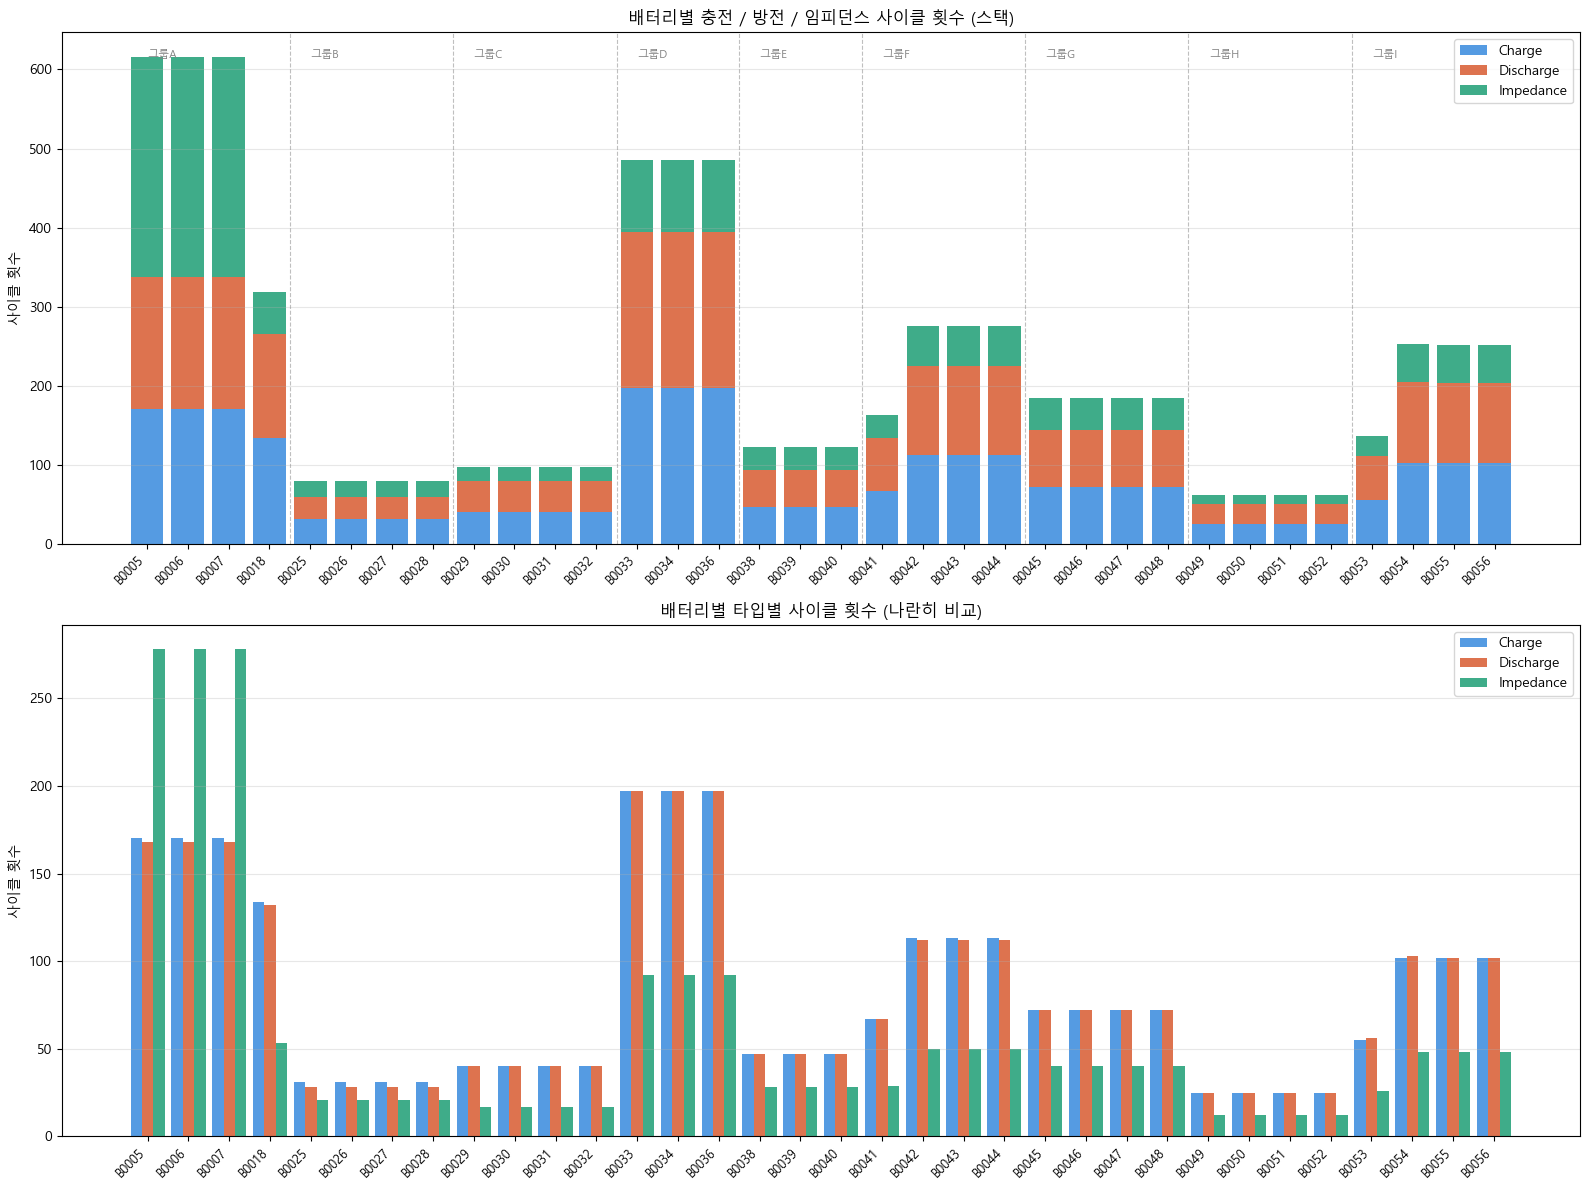


[저장 완료] battery_cycle_count.png


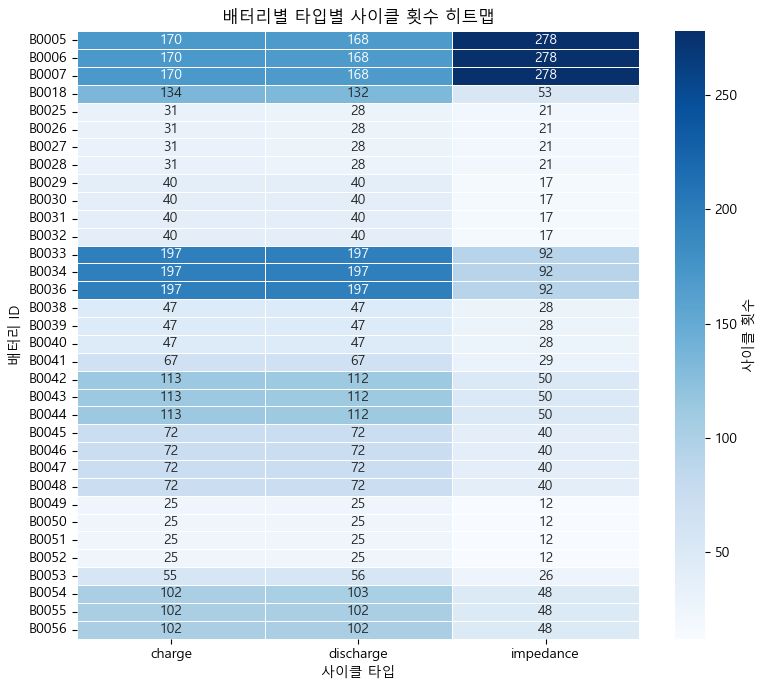

[저장 완료] battery_cycle_heatmap.png


In [16]:
count_table = (
    df.groupby(['battery_id', 'type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
 
# 컬럼 순서 통일
for col in ['charge', 'discharge', 'impedance']:
    if col not in count_table.columns:
        count_table[col] = 0
 
count_table = count_table[['battery_id', 'charge', 'discharge', 'impedance']]
count_table['total'] = count_table[['charge', 'discharge', 'impedance']].sum(axis=1)
 
# 그룹 컬럼 추가
group_map = {
    'B0005':'A','B0006':'A','B0007':'A','B0018':'A',
    'B0025':'B','B0026':'B','B0027':'B','B0028':'B',
    'B0029':'C','B0030':'C','B0031':'C','B0032':'C',
    'B0033':'D','B0034':'D','B0036':'D',
    'B0038':'E','B0039':'E','B0040':'E',
    'B0041':'F','B0042':'F','B0043':'F','B0044':'F',
    'B0045':'G','B0046':'G','B0047':'G','B0048':'G',
    'B0049':'H','B0050':'H','B0051':'H','B0052':'H',
    'B0053':'I','B0054':'I','B0055':'I','B0056':'I',
}
count_table['group'] = count_table['battery_id'].map(group_map)
 
# ------------------------------------------------------------
# 3. 콘솔 출력
# ------------------------------------------------------------
print("=" * 65)
print("배터리별 사이클 횟수")
print("=" * 65)
print(count_table.to_string(index=False))
 
print("\n" + "=" * 65)
print("그룹별 평균 사이클 횟수")
print("=" * 65)
group_summary = count_table.groupby('group')[['charge','discharge','impedance','total']].mean().round(1)
print(group_summary.to_string())
 
# ------------------------------------------------------------
# 4. 시각화 1 — 배터리별 스택 바차트
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
 
# 배터리 순서 정렬
ct = count_table.sort_values('battery_id').set_index('battery_id')
 
colors = {'charge': '#378ADD', 'discharge': '#D85A30', 'impedance': '#1D9E75'}
 
# 스택 바
x = range(len(ct))
bars_c = axes[0].bar(x, ct['charge'],    label='Charge',    color=colors['charge'],    alpha=0.85)
bars_d = axes[0].bar(x, ct['discharge'], label='Discharge', color=colors['discharge'], alpha=0.85,
                     bottom=ct['charge'])
bars_i = axes[0].bar(x, ct['impedance'], label='Impedance', color=colors['impedance'], alpha=0.85,
                     bottom=ct['charge'] + ct['discharge'])
 
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(ct.index, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('사이클 횟수')
axes[0].set_title('배터리별 충전 / 방전 / 임피던스 사이클 횟수 (스택)')
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)
 
# 그룹 구분선 추가
group_boundaries = []
prev_group = None
for i, bid in enumerate(ct.index):
    g = group_map.get(bid, '?')
    if g != prev_group:
        if prev_group is not None:
            axes[0].axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        axes[0].text(i, axes[0].get_ylim()[1] * 0.95 if axes[0].get_ylim()[1] > 0 else 700,
                     f'그룹{g}', fontsize=8, color='gray', ha='left')
        prev_group = g
 
# ------------------------------------------------------------
# 5. 시각화 2 — 타입별 개별 바차트 (3개 나란히)
# ------------------------------------------------------------
battery_ids = ct.index.tolist()
x2 = range(len(battery_ids))
width = 0.28
 
axes[1].bar([i - width for i in x2], ct['charge'],    width=width, label='Charge',    color=colors['charge'],    alpha=0.85)
axes[1].bar([i          for i in x2], ct['discharge'], width=width, label='Discharge', color=colors['discharge'], alpha=0.85)
axes[1].bar([i + width  for i in x2], ct['impedance'], width=width, label='Impedance', color=colors['impedance'], alpha=0.85)
 
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(battery_ids, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('사이클 횟수')
axes[1].set_title('배터리별 타입별 사이클 횟수 (나란히 비교)')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('battery_cycle_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[저장 완료] battery_cycle_count.png")
 
# ------------------------------------------------------------
# 6. 시각화 3 — 그룹별 히트맵
# ------------------------------------------------------------
fig2, ax = plt.subplots(figsize=(8, 7))
 
heatmap_data = count_table.set_index('battery_id')[['charge', 'discharge', 'impedance']]
 
sns.heatmap(
    heatmap_data,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '사이클 횟수'}
)
 
ax.set_title('배터리별 타입별 사이클 횟수 히트맵')
ax.set_xlabel('사이클 타입')
ax.set_ylabel('배터리 ID')
 
plt.tight_layout()
plt.savefig('battery_cycle_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("[저장 완료] battery_cycle_heatmap.png")
 

C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:113: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:113: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:113: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:113: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:114: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig('viz1_initial_capacity.png', dpi=150, bbox_inches='tight')
C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:11

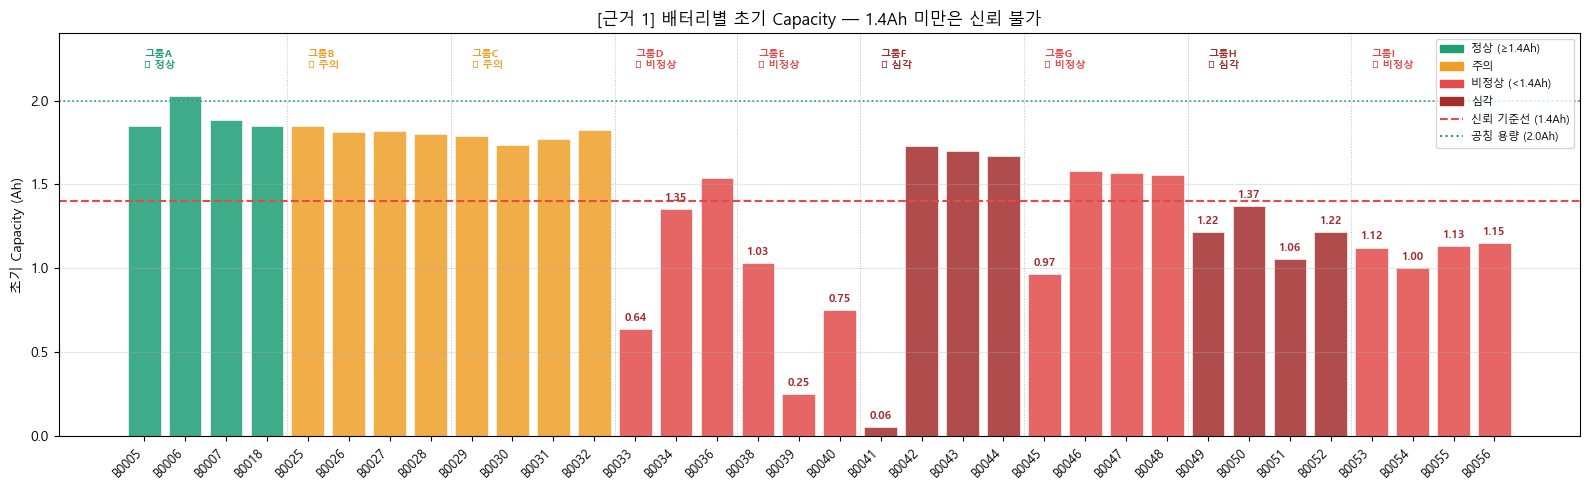

[저장] viz1_initial_capacity.png


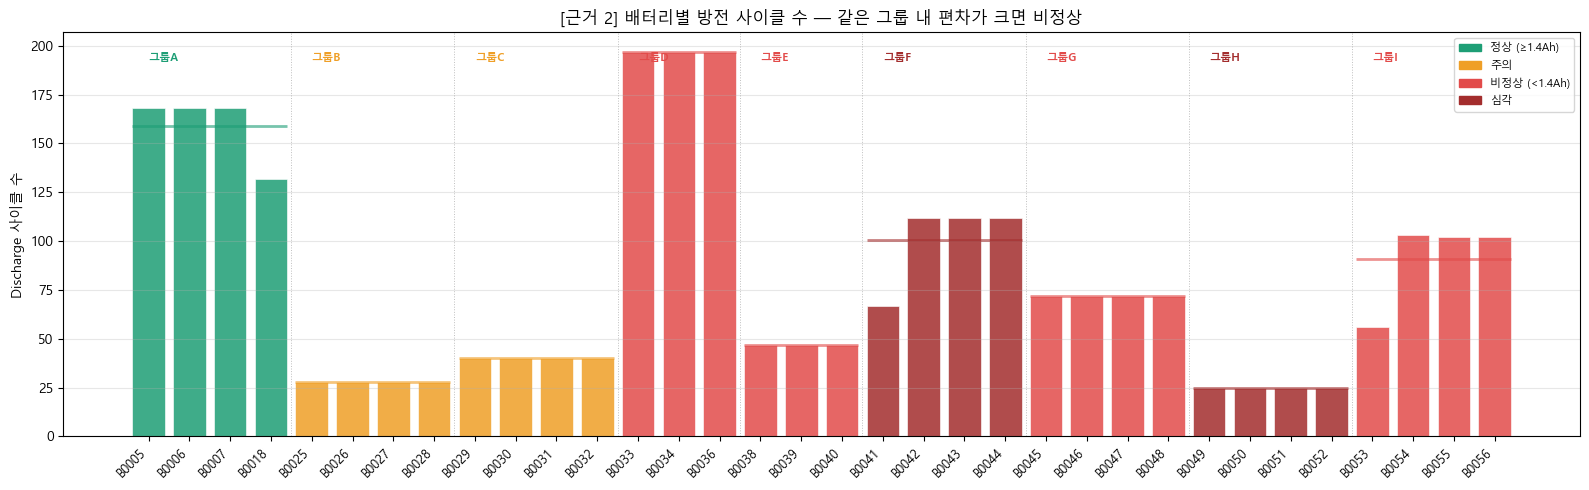

[저장] viz2_cycle_count_deviation.png


C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:209: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:209: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:210: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig('viz3_degradation_curves.png', dpi=150, bbox_inches='tight')
C:\Users\hoo58\AppData\Local\Temp\ipykernel_90184\305619907.py:210: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig('viz3_degradation_curves.png', dpi=150, bbox_inches='tight')
c:\Users\hoo58\project_lithium_battery_analysis_16team\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.


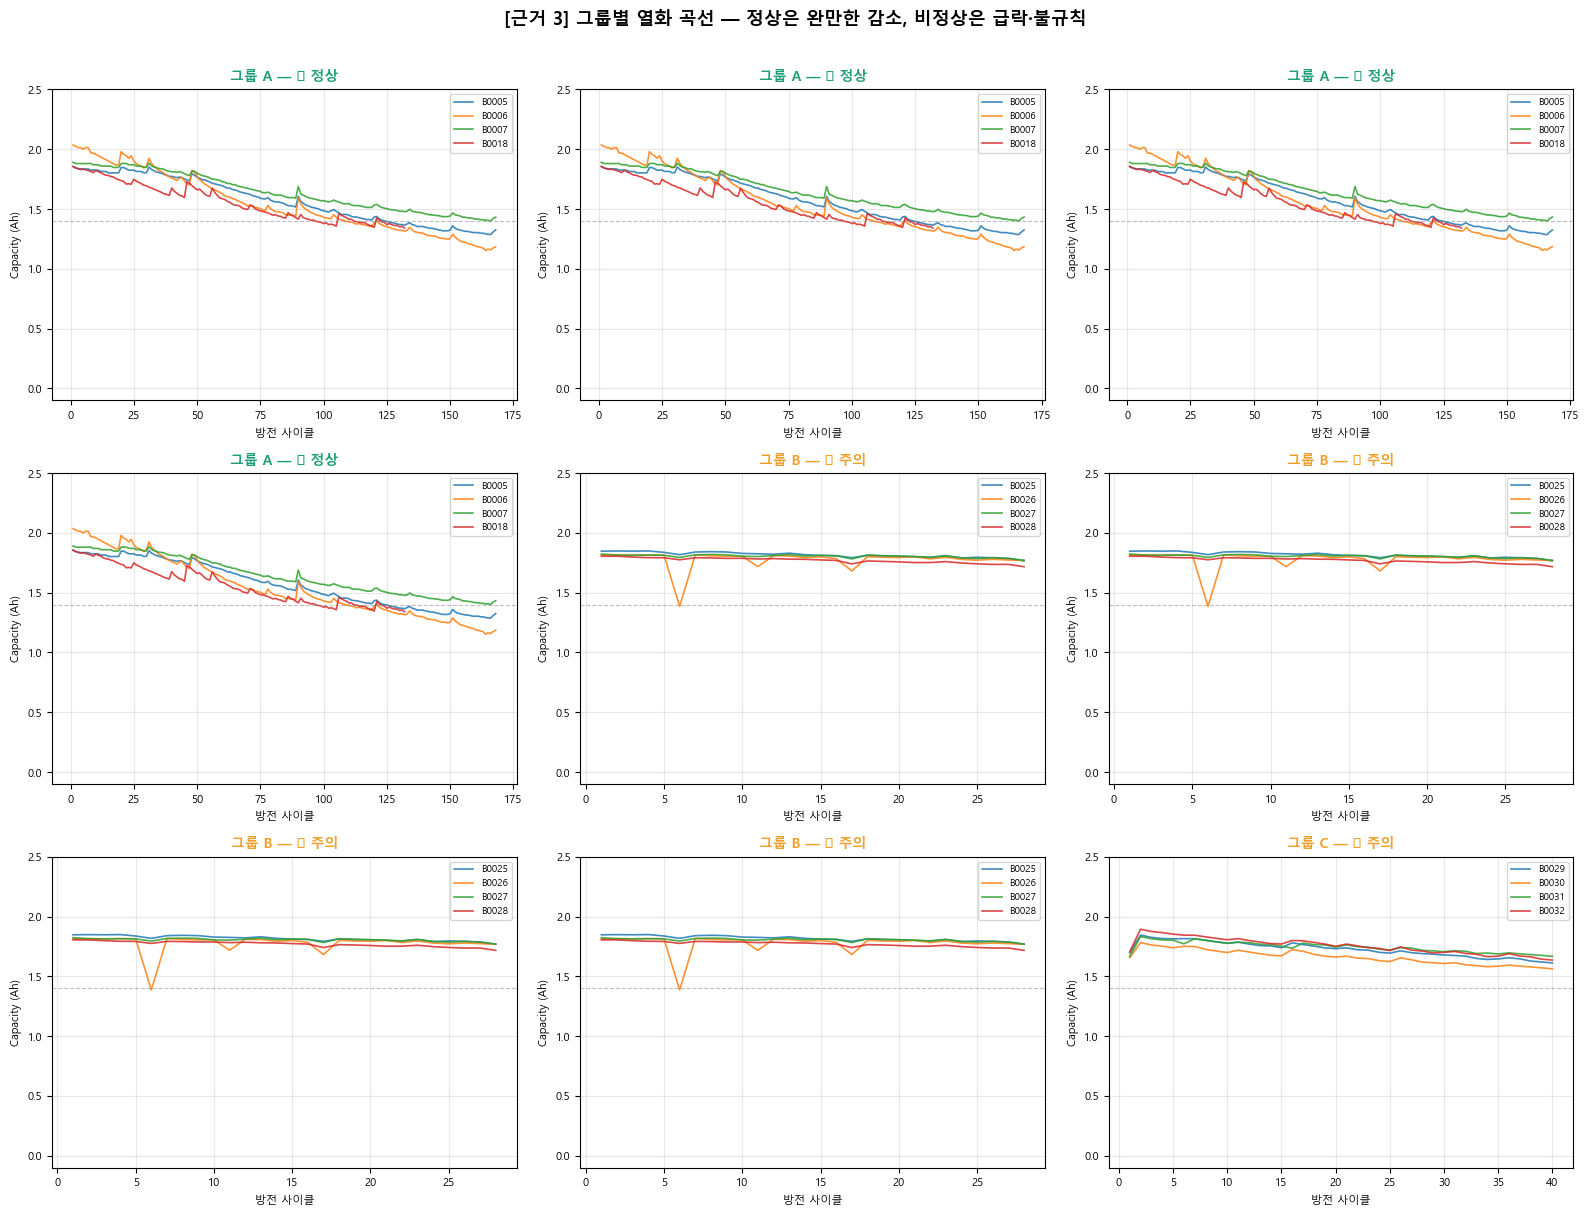

[저장] viz3_degradation_curves.png


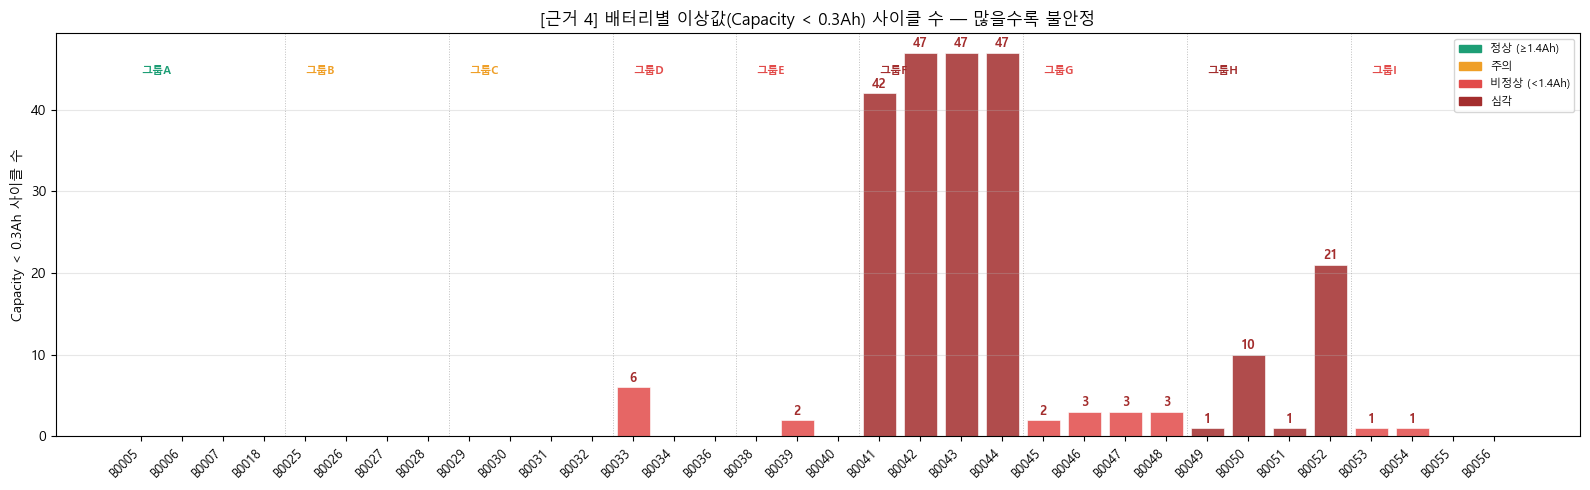

[저장] viz4_anomaly_count.png

✅ 전체 시각화 완료!
저장 파일: viz1_initial_capacity.png / viz2_cycle_count_deviation.png
         viz3_degradation_curves.png / viz4_anomaly_count.png


In [19]:
import matplotlib.patches as mpatches

group_map = {
    'B0005':'A','B0006':'A','B0007':'A','B0018':'A',
    'B0025':'B','B0026':'B','B0027':'B','B0028':'B',
    'B0029':'C','B0030':'C','B0031':'C','B0032':'C',
    'B0033':'D','B0034':'D','B0036':'D',
    'B0038':'E','B0039':'E','B0040':'E',
    'B0041':'F','B0042':'F','B0043':'F','B0044':'F',
    'B0045':'G','B0046':'G','B0047':'G','B0048':'G',
    'B0049':'H','B0050':'H','B0051':'H','B0052':'H',
    'B0053':'I','B0054':'I','B0055':'I','B0056':'I',
}
 
# 그룹별 판정 색상
status_color = {
    'A': '#1D9E75',   # 초록 = 정상
    'B': '#EF9F27',   # 주황 = 주의
    'C': '#EF9F27',
    'D': '#E24B4A',   # 빨강 = 비정상
    'E': '#E24B4A',
    'F': '#A32D2D',   # 진빨강 = 심각
    'G': '#E24B4A',
    'H': '#A32D2D',
    'I': '#E24B4A',
}
status_label = {
    'A': '✅ 정상',
    'B': '⚠ 주의',
    'C': '⚠ 주의',
    'D': '🔴 비정상',
    'E': '🔴 비정상',
    'F': '🔴 심각',
    'G': '🔴 비정상',
    'H': '🚨 심각',
    'I': '🔴 비정상',
}
 
df['group'] = df['battery_id'].map(group_map)
 
dis = df[df['type'] == 'discharge'].copy()
dis['Capacity'] = pd.to_numeric(dis['Capacity'], errors='coerce')
dis = dis.sort_values(['battery_id', 'test_id'])
dis['discharge_cycle_no'] = dis.groupby('battery_id').cumcount() + 1
dis['group'] = dis['battery_id'].map(group_map)
 
# 초기 Capacity (첫 3사이클 평균)
init_cap = dis.groupby('battery_id')['Capacity'].apply(
    lambda x: x.dropna().head(3).mean()
).rename('init_cap')
dis = dis.merge(init_cap, on='battery_id')
dis['SOH'] = (dis['Capacity'] / dis['init_cap'] * 100).round(2)
 
# ============================================================
# 시각화 1 — 배터리별 초기 Capacity (비정상 근거 1)
# 정상: 1.4Ah 이상 / 비정상: 그 이하
# ============================================================
fig1, ax1 = plt.subplots(figsize=(16, 5))
 
init_df = dis.groupby('battery_id')['init_cap'].first().reset_index()
init_df['group'] = init_df['battery_id'].map(group_map)
init_df = init_df.sort_values('battery_id')
 
bar_colors = [status_color[g] for g in init_df['group']]
bars = ax1.bar(init_df['battery_id'], init_df['init_cap'],
               color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
 
# 기준선 표시
ax1.axhline(y=1.4, color='#E24B4A', linestyle='--', linewidth=1.5,
            label='신뢰 기준선 (1.4Ah)')
ax1.axhline(y=2.0, color='#1D9E75', linestyle=':', linewidth=1.2,
            label='공칭 용량 (2.0Ah)')
 
# 값 표시 (비정상인 것만)
for bar, val, bid in zip(bars, init_df['init_cap'], init_df['battery_id']):
    if val < 1.4:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8,
                 color='#A32D2D', fontweight='bold')
 
ax1.set_xticks(range(len(init_df)))
ax1.set_xticklabels(init_df['battery_id'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('초기 Capacity (Ah)')
ax1.set_title('[근거 1] 배터리별 초기 Capacity — 1.4Ah 미만은 신뢰 불가')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 2.4)
 
# 그룹 레이블
prev_g = None
for i, (_, row) in enumerate(init_df.iterrows()):
    g = row['group']
    if g != prev_g:
        ax1.text(i, 2.3, f'그룹{g}\n{status_label[g]}',
                 ha='left', va='top', fontsize=7.5,
                 color=status_color[g], fontweight='bold')
        if prev_g is not None:
            ax1.axvline(x=i - 0.5, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        prev_g = g
 
# 범례 패치
patches = [
    mpatches.Patch(color='#1D9E75', label='정상 (≥1.4Ah)'),
    mpatches.Patch(color='#EF9F27', label='주의'),
    mpatches.Patch(color='#E24B4A', label='비정상 (<1.4Ah)'),
    mpatches.Patch(color='#A32D2D', label='심각'),
]
ax1.legend(handles=patches + [
    plt.Line2D([0],[0], color='#E24B4A', linestyle='--', label='신뢰 기준선 (1.4Ah)'),
    plt.Line2D([0],[0], color='#1D9E75', linestyle=':', label='공칭 용량 (2.0Ah)'),
], loc='upper right', fontsize=8)
 
plt.tight_layout()
plt.savefig('viz1_initial_capacity.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] viz1_initial_capacity.png')
 
# ============================================================
# 시각화 2 — 그룹별 사이클 수 균일성 (비정상 근거 2)
# 같은 그룹 안에서 사이클 수 편차가 크면 비정상
# ============================================================
count_table = (
    df.groupby(['battery_id', 'type']).size()
    .unstack(fill_value=0)
    .reset_index()
)
count_table['group'] = count_table['battery_id'].map(group_map)
count_table = count_table.sort_values('battery_id')
 
fig2, ax2 = plt.subplots(figsize=(16, 5))
 
x = range(len(count_table))
bar_colors2 = [status_color[g] for g in count_table['group']]
 
ax2.bar(x, count_table['discharge'], color=bar_colors2, alpha=0.85,
        edgecolor='white', linewidth=0.5, label='Discharge 사이클 수')
 
# 그룹 평균선
for grp in count_table['group'].unique():
    grp_idx = count_table[count_table['group'] == grp].index
    grp_positions = [list(count_table.index).index(i) for i in grp_idx]
    grp_mean = count_table.loc[grp_idx, 'discharge'].mean()
    ax2.hlines(grp_mean,
               min(grp_positions) - 0.4,
               max(grp_positions) + 0.4,
               colors=status_color[grp], linewidth=2, linestyle='-', alpha=0.6)
 
ax2.set_xticks(list(x))
ax2.set_xticklabels(count_table['battery_id'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Discharge 사이클 수')
ax2.set_title('[근거 2] 배터리별 방전 사이클 수 — 같은 그룹 내 편차가 크면 비정상')
ax2.grid(axis='y', alpha=0.3)
 
# 그룹 레이블 + 구분선
prev_g = None
for i, (_, row) in enumerate(count_table.iterrows()):
    g = row['group']
    if g != prev_g:
        ax2.text(i, ax2.get_ylim()[1] * 0.93,
                 f'그룹{g}', ha='left', fontsize=8,
                 color=status_color[g], fontweight='bold')
        if prev_g is not None:
            ax2.axvline(x=i - 0.5, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        prev_g = g
 
ax2.legend(handles=patches, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('viz2_cycle_count_deviation.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] viz2_cycle_count_deviation.png')
 
# ============================================================
# 시각화 3 — 그룹별 열화 곡선 (비정상 근거 3)
# 정상: 완만한 감소 / 비정상: 급락·불규칙
# ============================================================
fig3, axes3 = plt.subplots(3, 3, figsize=(16, 12))
axes3 = axes3.flatten()
 
for idx, grp in enumerate(sorted(group_map.values(), key=lambda x: x)):
    if idx >= 9:
        break
    ax = axes3[idx]
    grp_batteries = [b for b, g in group_map.items() if g == grp]
 
    for bid in sorted(grp_batteries):
        b_data = dis[dis['battery_id'] == bid]
        if len(b_data) == 0:
            continue
        ax.plot(b_data['discharge_cycle_no'], b_data['Capacity'],
                linewidth=1.2, label=bid, alpha=0.85)
 
    # 기준선
    ax.axhline(y=1.4, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'그룹 {grp} — {status_label[grp]}',
                 color=status_color[grp], fontsize=10, fontweight='bold')
    ax.set_xlabel('방전 사이클', fontsize=8)
    ax.set_ylabel('Capacity (Ah)', fontsize=8)
    ax.set_ylim(-0.1, 2.5)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)
 
    # 비정상 영역 음영
    if grp in ['F', 'H', 'I', 'D', 'E', 'G']:
        ax.axhspan(-0.1, 0.3, alpha=0.08, color='red', label='이상값 영역')
 
fig3.suptitle('[근거 3] 그룹별 열화 곡선 — 정상은 완만한 감소, 비정상은 급락·불규칙',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz3_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] viz3_degradation_curves.png')
 
# ============================================================
# 시각화 4 — Capacity 이상값 횟수 (비정상 근거 4)
# 배터리별 Capacity < 0.3인 사이클 수
# ============================================================
anomaly_count = dis.groupby('battery_id').apply(
    lambda x: (x['Capacity'].fillna(0) < 0.3).sum()
).reset_index()
anomaly_count.columns = ['battery_id', 'anomaly_count']
anomaly_count['group'] = anomaly_count['battery_id'].map(group_map)
anomaly_count = anomaly_count.sort_values('battery_id')
 
fig4, ax4 = plt.subplots(figsize=(16, 5))
 
bar_colors4 = [status_color[g] for g in anomaly_count['group']]
bars4 = ax4.bar(anomaly_count['battery_id'], anomaly_count['anomaly_count'],
                color=bar_colors4, alpha=0.85, edgecolor='white', linewidth=0.5)
 
# 값 표시 (0 초과만)
for bar, val in zip(bars4, anomaly_count['anomaly_count']):
    if val > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(val)), ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#A32D2D')
 
ax4.set_xticks(range(len(anomaly_count)))
ax4.set_xticklabels(anomaly_count['battery_id'], rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Capacity < 0.3Ah 사이클 수')
ax4.set_title('[근거 4] 배터리별 이상값(Capacity < 0.3Ah) 사이클 수 — 많을수록 불안정')
ax4.grid(axis='y', alpha=0.3)
 
# 그룹 레이블
prev_g = None
for i, (_, row) in enumerate(anomaly_count.iterrows()):
    g = row['group']
    if g != prev_g:
        ax4.text(i, ax4.get_ylim()[1] * 0.9 if ax4.get_ylim()[1] > 0 else 50,
                 f'그룹{g}', ha='left', fontsize=8,
                 color=status_color[g], fontweight='bold')
        if prev_g is not None:
            ax4.axvline(x=i - 0.5, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        prev_g = g
 
ax4.legend(handles=patches, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('viz4_anomaly_count.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] viz4_anomaly_count.png')
 
print('\n✅ 전체 시각화 완료!')
print('저장 파일: viz1_initial_capacity.png / viz2_cycle_count_deviation.png')
print('         viz3_degradation_curves.png / viz4_anomaly_count.png')